#Dataset Link: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio

#1) Nikhilesh Andole (35040343)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# -----------------------------
# 1. Install required libraries
# -----------------------------
!pip install -q librosa soundfile tensorflow scikit-learn seaborn

In [ ]:
# -----------------------------
# 2. Imports
# -----------------------------
# -----------------------
# System libraries
# -----------------------
import os
import zipfile
import shutil
import warnings
warnings.filterwarnings("ignore")

# -----------------------
# Data handling
# -----------------------
import numpy as np
import pandas as pd

# -----------------------
# Audio processing
# -----------------------
import librosa
import librosa.display
import soundfile as sf

# -----------------------
# Visualization
# -----------------------
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------
# Machine learning tools
# -----------------------
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

# -----------------------
# TensorFlow / Deep Learning
# -----------------------
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    Dropout,
    Bidirectional,
    LSTM,
    Dense,
    GlobalAveragePooling1D
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam

# -----------------------
# Print versions (optional)
# -----------------------
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

TensorFlow version: 2.19.0
NumPy version: 2.0.2
Pandas version: 2.2.2


In [ ]:
# -----------------------------
# 3. GPU check
# -----------------------------
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU detected:", gpus)
else:
    print("No GPU detected. In Colab: Runtime -> Change runtime type -> GPU")

GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# -----------------------------
# 4. Path define from drive
# -----------------------------

EXTRACT_DIR = "/content/drive/MyDrive/RAVDESS Emotional dataset"

In [ ]:
# -----------------------------
# 5. RAVDESS label mapping
# Filename format:
# 03-01-06-01-02-01-12.wav
# 3rd part = emotion ID
# -----------------------------
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}


In [ ]:
# -----------------------------
# 6. Build dataframe from files
# -----------------------------
data = []

for root, dirs, files in os.walk(EXTRACT_DIR):
    for file in files:
        if file.endswith(".wav"):
            file_path = os.path.join(root, file)

            parts = file.replace(".wav", "").split("-")
            if len(parts) == 7:
                emotion_id = parts[2]
                actor_id = parts[6]

                emotion = emotion_map.get(emotion_id, "unknown")

                data.append({
                    "path": file_path,
                    "file_name": file,
                    "emotion_id": emotion_id,
                    "emotion": emotion,
                    "actor": actor_id
                })

df = pd.DataFrame(data)

print("Total files:", len(df))
print(df.head())

Total files: 2880
                                                path  \
0  /content/drive/MyDrive/RAVDESS Emotional datas...   
1  /content/drive/MyDrive/RAVDESS Emotional datas...   
2  /content/drive/MyDrive/RAVDESS Emotional datas...   
3  /content/drive/MyDrive/RAVDESS Emotional datas...   
4  /content/drive/MyDrive/RAVDESS Emotional datas...   

                  file_name emotion_id  emotion actor  
0  03-01-04-01-02-01-01.wav         04      sad    01  
1  03-01-06-01-02-01-01.wav         06  fearful    01  
2  03-01-07-02-01-02-01.wav         07  disgust    01  
3  03-01-04-01-02-02-01.wav         04      sad    01  
4  03-01-06-02-01-02-01.wav         06  fearful    01  


#2) Pamulapati Mahesh Babu (35045493)

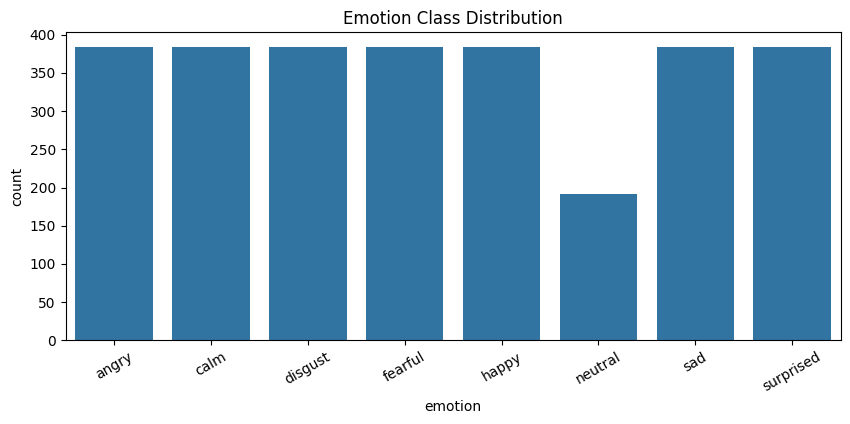

In [ ]:
# -----------------------------
# 7. Class distribution
# -----------------------------
plt.figure(figsize=(10, 4))
sns.countplot(x="emotion", data=df, order=sorted(df["emotion"].unique()))
plt.title("Emotion Class Distribution")
plt.xticks(rotation=30)
plt.show()

In [ ]:
# -----------------------------
# 8. Audio augmentation functions
# -----------------------------
def add_noise(signal, noise_factor=0.005):
    noise = np.random.randn(len(signal))
    return signal + noise_factor * noise

def shift_signal(signal, shift_max=0.2):
    shift = int(np.random.uniform(-shift_max, shift_max) * len(signal))
    return np.roll(signal, shift)

def change_pitch(signal, sr, n_steps=2):
    return librosa.effects.pitch_shift(y=signal, sr=sr, n_steps=n_steps)

In [ ]:
# -----------------------------
# 9. Feature extraction settings
# -----------------------------
SAMPLE_RATE = 22050
DURATION = 3.0
SAMPLES_PER_TRACK = int(SAMPLE_RATE * DURATION)
N_MFCC = 40
MAX_PAD_LEN = 130   # fixed time frames for MFCC matrix

def load_audio_fixed(path, sr=SAMPLE_RATE, duration=DURATION):
    signal, sr = librosa.load(path, sr=sr)

    if len(signal) > SAMPLES_PER_TRACK:
        signal = signal[:SAMPLES_PER_TRACK]
    else:
        padding = SAMPLES_PER_TRACK - len(signal)
        signal = np.pad(signal, (0, padding), mode='constant')

    return signal, sr

def extract_mfcc(signal, sr, n_mfcc=N_MFCC, max_pad_len=MAX_PAD_LEN):
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)
    mfcc = librosa.util.normalize(mfcc)

    if mfcc.shape[1] < max_pad_len:
        pad_width = max_pad_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_pad_len]

    return mfcc.T   # shape: (time, features)

#3) Rajagopala Rao Bandaru (35050526)

In [ ]:
# -----------------------------
# 10. Create dataset
# Original + optional augmentations
# -----------------------------
X = []
y = []
groups = []

USE_AUGMENTATION = True

for _, row in df.iterrows():
    try:
        signal, sr = load_audio_fixed(row["path"])

        # Original
        mfcc = extract_mfcc(signal, sr)
        X.append(mfcc)
        y.append(row["emotion"])
        groups.append(row["actor"])

        if USE_AUGMENTATION:
            # Noise augmentation
            aug1 = add_noise(signal)
            mfcc1 = extract_mfcc(aug1, sr)
            X.append(mfcc1)
            y.append(row["emotion"])
            groups.append(row["actor"])

            # Shift augmentation
            aug2 = shift_signal(signal)
            mfcc2 = extract_mfcc(aug2, sr)
            X.append(mfcc2)
            y.append(row["emotion"])
            groups.append(row["actor"])

    except Exception as e:
        print("Error processing:", row["path"], "->", e)

X = np.array(X, dtype=np.float32)
y = np.array(y)
groups = np.array(groups)

print("Feature shape:", X.shape)   # (samples, time_steps, n_mfcc)
print("Labels shape:", y.shape)

Feature shape: (8640, 130, 40)
Labels shape: (8640,)


In [ ]:
# -----------------------------
# 11. Encode labels
# -----------------------------
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

print("Classes:", list(label_encoder.classes_))


Classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]


In [ ]:
# -----------------------------
# 12. Group-based split by actor
# avoids leakage across same actor
# -----------------------------
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss1.split(X, y_encoded, groups=groups))

X_train_full, X_test = X[train_idx], X[test_idx]
y_train_full, y_test = y_encoded[train_idx], y_encoded[test_idx]
groups_train_full = groups[train_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx2, val_idx = next(gss2.split(X_train_full, y_train_full, groups=groups_train_full))

X_train, X_val = X_train_full[train_idx2], X_train_full[val_idx]
y_train, y_val = y_train_full[train_idx2], y_train_full[val_idx]

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (5400, 130, 40) (5400,)
Val  : (1440, 130, 40) (1440,)
Test : (1800, 130, 40) (1800,)


In [ ]:
# -----------------------------
# 13. Class weights for imbalance
# -----------------------------
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {i: weights[i] for i in range(len(classes))}
print("Class weights:", class_weights)


Class weights: {0: np.float64(0.9375), 1: np.float64(0.9375), 2: np.float64(0.9375), 3: np.float64(0.9375), 4: np.float64(0.9375), 5: np.float64(1.875), 6: np.float64(0.9375), 7: np.float64(0.9375)}


#4) Ashiq shaik (35033254)

In [ ]:
# -----------------------------
# 14. Build CNN + BiLSTM model
# -----------------------------
input_shape = (X_train.shape[1], X_train.shape[2])

inputs = Input(shape=input_shape)

x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.3)(x)

x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(32, return_sequences=True))(x)
x = Dropout(0.3)(x)

x = GlobalAveragePooling1D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 130, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 130, 64)        │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 130, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 65, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 65, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 65, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 65, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32, 64)         │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,600 (713.28 KB)

 Trainable params: 182,216 (711.78 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# -----------------------------
# 15. Callbacks
# -----------------------------
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        "best_speech_emotion_model.keras",
        monitor='val_loss',
        save_best_only=True
    )
]

In [ ]:
# -----------------------------
# 16. Train model
# -----------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.2777 - loss: 1.8319 - val_accuracy: 0.1333 - val_loss: 2.6314 - learning_rate: 0.0010
Epoch 2/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.5069 - loss: 1.3055 - val_accuracy: 0.1403 - val_loss: 3.5516 - learning_rate: 0.0010
Epoch 3/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6551 - loss: 0.9805 - val_accuracy: 0.2257 - val_loss: 3.6394 - learning_rate: 0.0010
Epoch 4/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7144 - loss: 0.7835 - val_accuracy: 0.3403 - val_loss: 2.3488 - learning_rate: 0.0010
Epoch 5/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.7829 - loss: 0.5989 - val_accuracy: 0.4847 - val_loss: 1.9296 - learning_rate: 0.0010
Epoch 6/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8466 - loss: 0.4533 - val_accuracy: 0.5069 - val_loss: 2.0607 - learning_rate: 0.0010
Epoch 7/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8588 - loss: 0

#5) Mohammed Suleman (35049043)

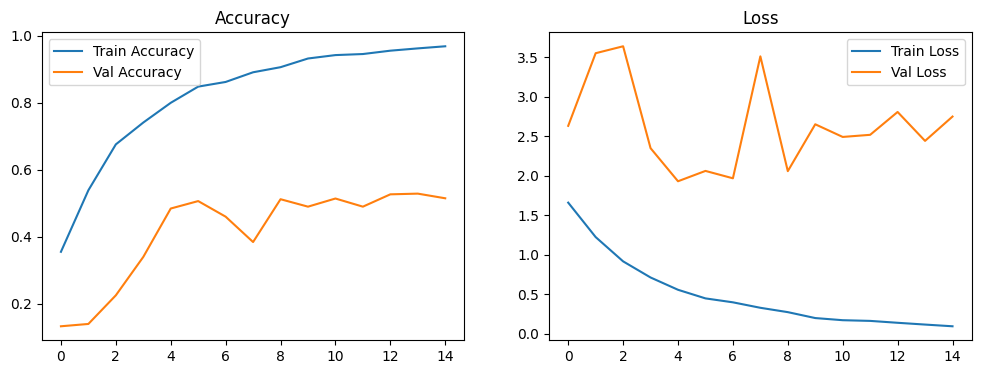

In [ ]:
# -----------------------------
# 17. Plot training curves
# -----------------------------
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [ ]:
# -----------------------------
# 18. Evaluate on test set
# -----------------------------
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average='weighted'
)

print(f"Test Accuracy : {acc:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall   : {recall:.4f}")
print(f"Test F1-Score : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
Test Accuracy : 0.3639
Test Precision: 0.5167
Test Recall   : 0.3639
Test F1-Score : 0.3772

Classification Report:

              precision    recall  f1-score   support

       angry       0.80      0.47      0.60       240
        calm       0.66      0.16      0.26       240
     disgust       0.56      0.24      0.33       240
     fearful       0.31      0.56      0.40       240
       happy       0.68      0.33      0.44       240
     neutral       0.52      0.19      0.28       120
         sad       0.17      0.50      0.25       240
   surprised       0.45      0.38      0.41       240

    accuracy                           0.36      1800
   macro avg       0.52      0.35      0.37      1800
weighted avg       0.52      0.36      0.38      1800



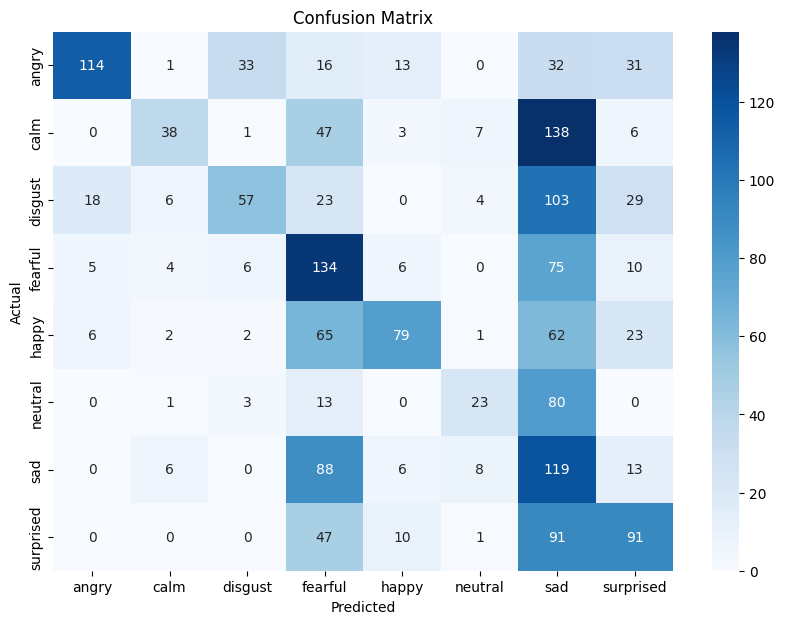

In [ ]:
# -----------------------------
# 19. Confusion matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# -----------------------------
# 20. Save label classes
# -----------------------------
np.save("speech_label_classes.npy", label_encoder.classes_)
print("Model and label classes saved.")

Model and label classes saved.


In [ ]:
# -----------------------------
# 21. Single file prediction function
# -----------------------------
def predict_emotion(file_path, model, label_encoder):
    signal, sr = load_audio_fixed(file_path)
    mfcc = extract_mfcc(signal, sr)
    mfcc = np.expand_dims(mfcc, axis=0)  # batch dimension

    pred_probs = model.predict(mfcc, verbose=0)
    pred_idx = np.argmax(pred_probs, axis=1)[0]
    pred_label = label_encoder.inverse_transform([pred_idx])[0]

    return pred_label, pred_probs[0]

# Example:
sample_file = df.iloc[0]["path"]
pred_label, pred_probs = predict_emotion(sample_file, model, label_encoder)
print("Sample file:", sample_file)
print("Predicted emotion:", pred_label)


Sample file: /content/drive/MyDrive/RAVDESS Emotional dataset/Actor_01/03-01-04-01-02-01-01.wav
Predicted emotion: calm
